
# Quantum magic / SRE-2

Notebook para carregar os resultados gerados pelos scripts de **quantum magic** e produzir figuras no mesmo padrão dos notebooks de Wigner, coerência e emaranhamento.

Ele funciona para três tipos de varredura:

- `cos`: variação de $\omega$ em `w_list.npy`;
- `gauss var ep`: variação de $\epsilon$ em `ep_list.npy` ou `epsilon_list.npy`;
- `gauss var T`: variação de $T$ em `T_list.npy`.

A quantidade plotada é a Stabilizer Rényi Entropy de ordem 2, $M_2$.


In [10]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 0. Funções auxiliares


In [11]:
MAGIC_ROOT = "results/magic"


def _as_real_matrix(arr):
    """Converte listas/arrays possivelmente complexos em matriz real [scan, tempo]."""
    arr = np.asarray(arr, dtype=object)
    if arr.ndim == 1:
        mat = np.vstack([np.asarray(row, dtype=np.complex128).ravel() for row in arr])
    else:
        mat = np.asarray(arr, dtype=np.complex128)
    return np.real_if_close(mat).astype(float)


def _as_real_vector(arr):
    return np.real_if_close(np.asarray(arr, dtype=np.complex128).ravel()).astype(float)


def _edges_from_centers(x):
    """Centros -> bordas, para usar pcolormesh mesmo com malha não-uniforme."""
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        dx = 1.0
        return np.array([x[0] - dx/2, x[0] + dx/2])
    dx = np.diff(x)
    edges = np.empty(x.size + 1, dtype=float)
    edges[1:-1] = x[:-1] + dx / 2
    edges[0] = x[0] - dx[0] / 2
    edges[-1] = x[-1] + dx[-1] / 2
    return edges


def find_magic_experiments(scan_name=None, root=MAGIC_ROOT):
    """
    Busca automaticamente pastas em results/magic.

    scan_name pode ser:
    - "w"       -> procura w_list.npy
    - "T"       -> procura T_list.npy
    - "ep"      -> procura ep_list.npy ou epsilon_list.npy
    - None      -> retorna todas as pastas com t.npy
    """
    folders = []
    for folder in glob.glob(os.path.join(root, "*")):
        if not os.path.isdir(folder):
            continue
        if not os.path.exists(os.path.join(folder, "t.npy")):
            continue

        if scan_name is None:
            folders.append(folder)
        elif scan_name == "ep":
            if (
                os.path.exists(os.path.join(folder, "ep_list.npy"))
                or os.path.exists(os.path.join(folder, "epsilon_list.npy"))
            ):
                folders.append(folder)
        else:
            if os.path.exists(os.path.join(folder, f"{scan_name}_list.npy")):
                folders.append(folder)

    # mais recentes primeiro
    folders = sorted(folders, key=os.path.getmtime, reverse=True)
    return folders


def latest_magic_experiment(scan_name, root=MAGIC_ROOT):
    folders = find_magic_experiments(scan_name=scan_name, root=root)
    if len(folders) == 0:
        return None
    return folders[0]


def load_magic(experiment, root=MAGIC_ROOT):
    """
    Carrega uma pasta de resultados de quantum magic.

    experiment pode ser:
    - nome da pasta: "magic_cos1"
    - caminho completo: "results/magic/magic_cos1"
    """
    if os.path.isdir(experiment):
        folder = experiment
        experiment_name = os.path.basename(folder)
    else:
        folder = os.path.join(root, experiment)
        experiment_name = experiment

    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Pasta não encontrada: {folder}")

    t = _as_real_vector(np.load(os.path.join(folder, "t.npy"), allow_pickle=True))

    if os.path.exists(os.path.join(folder, "w_list.npy")):
        scan = _as_real_vector(np.load(os.path.join(folder, "w_list.npy"), allow_pickle=True))
        scan_name = "w"
        scan_label = r"$\omega$"
        scan_key = "w"
    elif os.path.exists(os.path.join(folder, "T_list.npy")):
        scan = _as_real_vector(np.load(os.path.join(folder, "T_list.npy"), allow_pickle=True))
        scan_name = "T"
        scan_label = r"$T$"
        scan_key = "T"
    elif os.path.exists(os.path.join(folder, "ep_list.npy")):
        scan = _as_real_vector(np.load(os.path.join(folder, "ep_list.npy"), allow_pickle=True))
        scan_name = "ep"
        scan_label = r"$\epsilon$"
        scan_key = "epsilon"
    elif os.path.exists(os.path.join(folder, "epsilon_list.npy")):
        scan = _as_real_vector(np.load(os.path.join(folder, "epsilon_list.npy"), allow_pickle=True))
        scan_name = "ep"
        scan_label = r"$\epsilon$"
        scan_key = "epsilon"
    else:
        raise FileNotFoundError("Não encontrei w_list.npy, T_list.npy, ep_list.npy ou epsilon_list.npy.")

    const = _as_real_vector(np.load(os.path.join(folder, "const.npy"), allow_pickle=True))
    const_aberto = _as_real_vector(np.load(os.path.join(folder, "const_aberto.npy"), allow_pickle=True))
    var = _as_real_matrix(np.load(os.path.join(folder, "var.npy"), allow_pickle=True))
    var_aberto = _as_real_matrix(np.load(os.path.join(folder, "var_aberto.npy"), allow_pickle=True))

    D_wt = var - const[None, :]
    D_wt_aberto = var_aberto - const_aberto[None, :]

    args = {}
    args_path = os.path.join(folder, "args.json")
    if os.path.exists(args_path):
        with open(args_path, "r", encoding="utf-8") as f:
            args = json.load(f)

    info = {
        "folder": folder,
        "experiment": experiment_name,
        "scan_name": scan_name,
        "scan_label": scan_label,
        "scan_key": scan_key,
        "args": args,
    }

    return scan, var, D_wt, var_aberto, D_wt_aberto, const, const_aberto, t, info


In [12]:
def g_t_notebook(t, args):
    """Versão local simples da função de acoplamento para plotar g(t)."""
    t = np.asarray(t, dtype=float)
    coupling = args.get("coupling", "cos")
    g0 = float(args.get("g0", 1.0))

    if coupling == "cos":
        w = float(args.get("w", 0.0))
        phi = float(args.get("phi", 0.0))
        return g0 * np.cos(w * t + phi)

    if coupling == "cos_mod":
        lam = float(args.get("lambda", 1.0))
        w = float(args.get("w", 0.0))
        phi = float(args.get("phi", 0.0))
        return g0 + lam * np.cos(w * t + phi)

    if coupling == "sin":
        w = float(args.get("w", 0.0))
        return g0 * np.sin(w * t)

    if coupling == "linear":
        w = float(args.get("w", 0.0))
        phi = float(args.get("phi", 0.0))
        return g0 * (w * t + phi)

    if coupling == "exp":
        w = float(args.get("w", 0.0))
        phi = float(args.get("phi", 0.0))
        return g0 * np.exp(w * t + phi)

    if coupling == "gauss":
        sigma = float(args.get("sigma", -1.0))
        T = float(args.get("T", 0.0))
        epsilon = float(args.get("epsilon", args.get("ep", 1.0)))
        return g0 * np.exp(sigma * ((t - T) / epsilon)**2)

    raise ValueError(f"Coupling não reconhecido para plot: {coupling}")


def plot_selected_couplings(t, scan, info, indices=None):
    """Plota g(t) para alguns valores da varredura, seguindo o estilo dos outros notebooks."""
    args = dict(info.get("args", {}))
    if len(args) == 0:
        print("Sem args.json: não vou plotar g(t).")
        return

    scan_key = info["scan_key"]
    scan_label = info["scan_label"]

    if indices is None:
        indices = [0, len(scan)//2, -1]

    plt.figure(figsize=(8, 5))
    plt.plot(t, np.ones_like(t) * float(args.get("g0", 1.0)), lw=3, label=r"$g_0$")

    for idx in indices:
        args_i = dict(args)
        args_i[scan_key] = float(scan[idx])
        g = g_t_notebook(t, args_i)
        plt.plot(t, g, lw=3, label=rf"{scan_label} = {scan[idx]:.4g}")

    plt.xlabel(r"$t$", fontsize=20)
    plt.ylabel(r"$g(t)$", fontsize=20)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)
    plt.grid(True)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()


In [13]:
def plot_const_comparison(t, const, const_aberto, save=False, info=None):
    plt.figure(figsize=(8, 5))
    plt.plot(t, const, lw=2.0, label=r"$g_0$")
    plt.plot(t, const_aberto, lw=2.0, linestyle="--", label=r"$g_0$ aberto")
    plt.xlabel(r"$t$", fontsize=20)
    plt.ylabel(r"$M_2$", fontsize=20)
    plt.title("Quantum magic/SRE-2: acoplamento constante")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()

    if save and info is not None:
        plot_dir = os.path.join(info["folder"], "plots")
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(os.path.join(plot_dir, "magic_const_comparison.png"), dpi=200)
    plt.show()


def plot_magic_and_difference(t, scan, M_wt, D_wt, info, cmap_var=None, cmap_diff=None, save=False, suffix="fechado"):
    t_edges = _edges_from_centers(t)
    scan_edges = _edges_from_centers(scan)
    scan_label = info["scan_label"]

    # ==========================
    # Plot 1: Magic
    # ==========================
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(
        t_edges, scan_edges, M_wt,
        shading="auto",
        cmap=cmap_var
    )
    plt.xlabel(r"$t$", fontsize=20)
    plt.ylabel(scan_label, fontsize=20)
    plt.colorbar(label=r"$M_2$")
    plt.title(f"Quantum magic/SRE-2: {info['experiment']} ({suffix})")
    plt.tight_layout()

    if save:
        plot_dir = os.path.join(info["folder"], "plots")
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(os.path.join(plot_dir, f"magic_heatmap_{suffix}_{info['scan_name']}.png"), dpi=200)
    plt.show()

    # ==========================
    # Plot 2: Diferença
    # ==========================
    plt.figure(figsize=(8, 5))
    plt.pcolormesh(
        t_edges, scan_edges, D_wt,
        shading="auto",
        cmap=cmap_diff
    )
    plt.xlabel(r"$t$", fontsize=20)
    plt.ylabel(scan_label, fontsize=20)
    plt.colorbar(label=r"$\Delta M_2$")
    plt.title(f"Diferença: variável - constante ({suffix})")
    plt.tight_layout()

    if save:
        plot_dir = os.path.join(info["folder"], "plots")
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(os.path.join(plot_dir, f"magic_difference_{suffix}_{info['scan_name']}.png"), dpi=200)
    plt.show()


def plot_selected_magic(t, scan, M_wt, const, info, indices=None, save=False, suffix="fechado"):
    if indices is None:
        indices = [0, len(scan)//2, -1]

    scan_label = info["scan_label"]

    plt.figure(figsize=(8, 5))
    plt.plot(t, const, lw=2.5, label=r"$g_0$")

    for idx in indices:
        plt.plot(t, M_wt[idx], lw=2.0, label=rf"{scan_label} = {scan[idx]:.4g}")

    plt.xlabel(r"$t$", fontsize=20)
    plt.ylabel(r"$M_2$", fontsize=20)
    plt.title(f"Curvas selecionadas de quantum magic ({suffix})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()

    if save:
        plot_dir = os.path.join(info["folder"], "plots")
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(os.path.join(plot_dir, f"magic_selected_curves_{suffix}_{info['scan_name']}.png"), dpi=200)
    plt.show()


def plot_final_time_scan(scan, var, var_aberto, info, save=False):
    scan_label = info["scan_label"]

    plt.figure(figsize=(8, 5))
    plt.plot(scan, var[:, -1], lw=2.0, label="var")
    plt.plot(scan, var_aberto[:, -1], lw=2.0, linestyle="--", label="var_aberto")
    plt.xlabel(scan_label, fontsize=20)
    plt.ylabel(r"$M_2(t_{final})$", fontsize=20)
    plt.title("Quantum magic/SRE-2 no tempo final")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()

    if save:
        plot_dir = os.path.join(info["folder"], "plots")
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(os.path.join(plot_dir, f"magic_final_time_scan_{info['scan_name']}.png"), dpi=200)
    plt.show()


def save_magic_summary(scan, var, var_aberto, info):
    summary = pd.DataFrame({
        info["scan_name"]: scan,
        "var_M2_max": np.max(var, axis=1),
        "var_M2_mean": np.mean(var, axis=1),
        "var_M2_final": var[:, -1],
        "var_aberto_M2_max": np.max(var_aberto, axis=1),
        "var_aberto_M2_mean": np.mean(var_aberto, axis=1),
        "var_aberto_M2_final": var_aberto[:, -1],
    })
    out = os.path.join(info["folder"], f"magic_summary_per_{info['scan_name']}.csv")
    summary.to_csv(out, index=False)
    print(f"Resumo salvo em: {out}")
    return summary


def run_magic_plots(experiment, indices=None, save=True):
    scan, var, D_wt, var_aberto, D_wt_aberto, const, const_aberto, t, info = load_magic(experiment)
    print(f"Experimento: {info['experiment']}")
    print(f"Pasta: {info['folder']}")
    print(f"Parâmetro: {info['scan_name']} | pontos: {len(scan)} | tempos: {len(t)}")

    plot_selected_couplings(t, scan, info, indices=indices)
    plot_const_comparison(t, const, const_aberto, save=save, info=info)


    plot_magic_and_difference(
        t=t,
        scan=scan,
        M_wt=var_aberto,
        D_wt=D_wt_aberto,
        info=info,
        save=save,
        suffix="aberto"
    )


    plot_selected_magic(
        t=t,
        scan=scan,
        M_wt=var_aberto,
        const=const_aberto,
        info=info,
        indices=indices,
        save=save,
        suffix="aberto"
    )

    plot_final_time_scan(scan, var, var_aberto, info, save=save)
    summary = save_magic_summary(scan, var, var_aberto, info)
    return scan, var, var_aberto, const, const_aberto, t, info, summary



# 1. Ver quais resultados existem

Esta célula lista automaticamente as pastas dentro de `results/magic`.


In [14]:
print("Todas as pastas encontradas:")
for f in find_magic_experiments(None):
    print(" -", f)

print("\nÚltima pasta cos / w:", latest_magic_experiment("w"))
print("Última pasta gauss / epsilon:", latest_magic_experiment("ep"))
print("Última pasta gauss / T:", latest_magic_experiment("T"))

Todas as pastas encontradas:
 - results/magic/magic_gauss2
 - results/magic/magic_gauss1
 - results/magic/magic_cos1

Última pasta cos / w: results/magic/magic_cos1
Última pasta gauss / epsilon: results/magic/magic_gauss1
Última pasta gauss / T: results/magic/magic_gauss2



# 2. Cosseno: variação de $\omega$

Aqui carregamos a pasta que contém `w_list.npy`, isto é, o caso do acoplamento

\begin{equation}
    g(t) = g_0 \cos(\omega t + \phi).
\end{equation}


Experimento: magic_cos1
Pasta: results/magic/magic_cos1
Parâmetro: w | pontos: 200 | tempos: 300


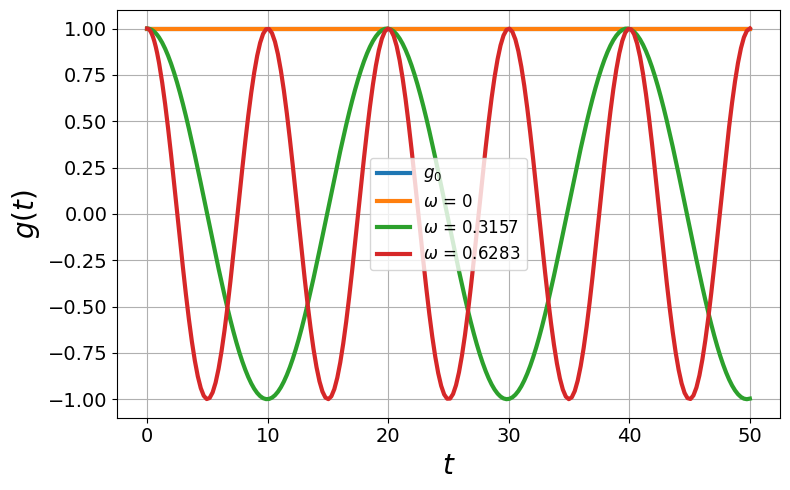

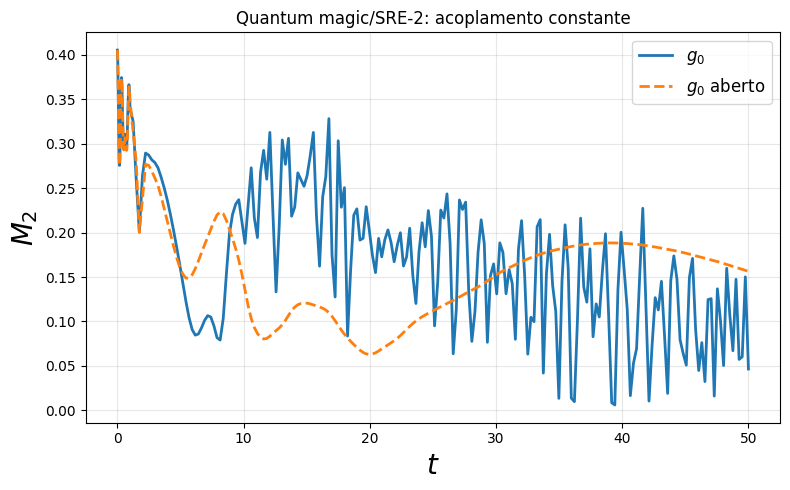

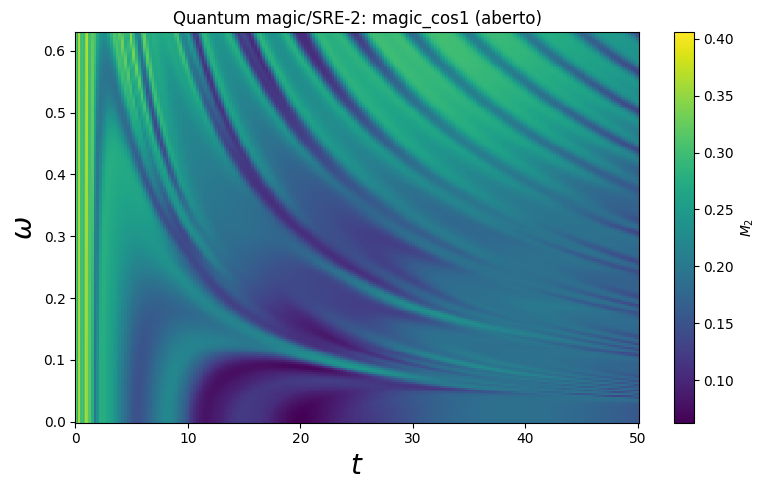

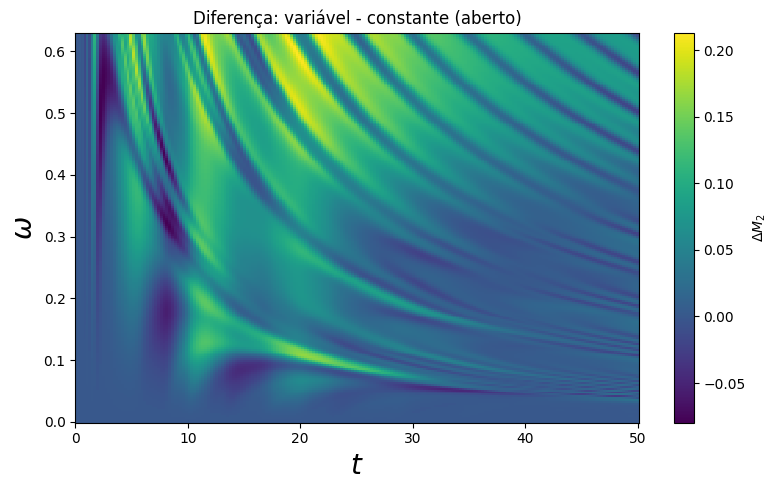

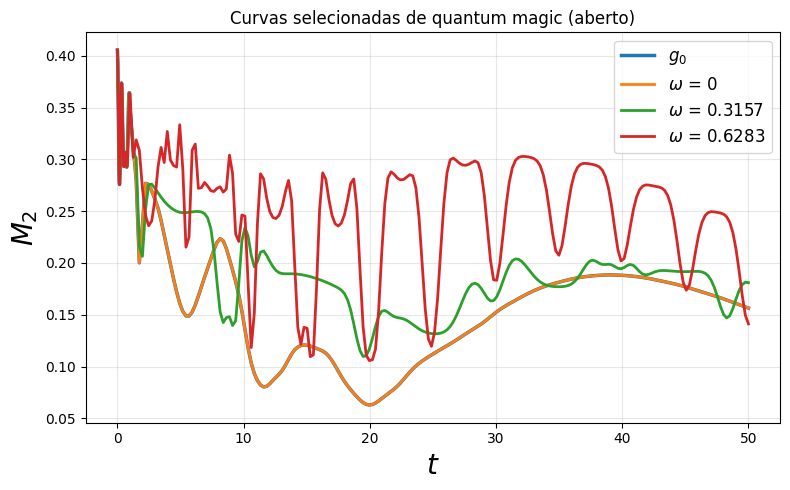

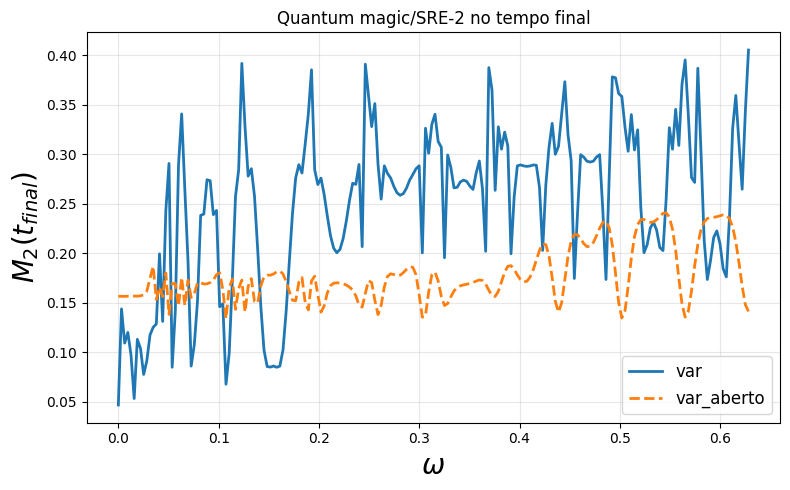

Resumo salvo em: results/magic/magic_cos1/magic_summary_per_w.csv


In [15]:
cos_experiment = latest_magic_experiment("w")
# Se quiser forçar manualmente, use por exemplo:
# cos_experiment = "magic_cos1"

if cos_experiment is None:
    print("Não encontrei pasta com w_list.npy. Rode o script do caso cos ou ajuste cos_experiment manualmente.")
else:
    cos_results = run_magic_plots(cos_experiment, indices=None, save=True)


# 3. Gaussiana: variação de $\epsilon$

Aqui carregamos a pasta que contém `ep_list.npy` ou `epsilon_list.npy`, isto é, o caso gaussiano variando a largura do pulso:

\begin{equation}
    g(t) = g_0 \exp\left[\sigma\left(\frac{t-T}{\epsilon}\right)^2\right].
\end{equation}


Experimento: magic_gauss1
Pasta: results/magic/magic_gauss1
Parâmetro: ep | pontos: 100 | tempos: 300


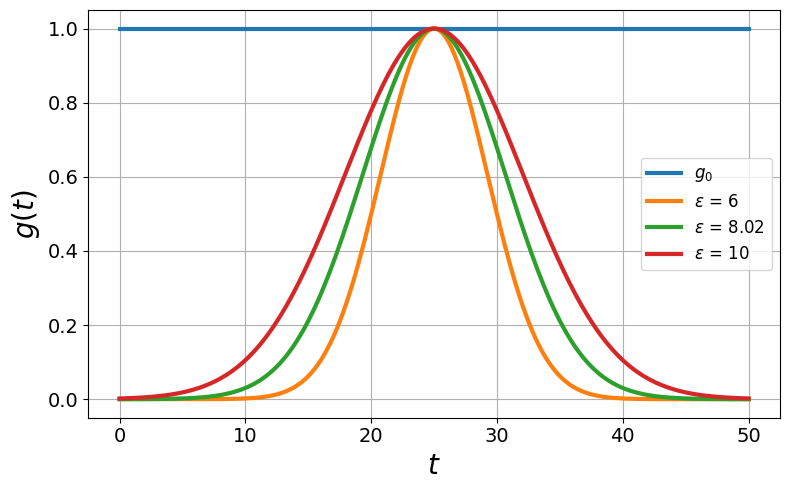

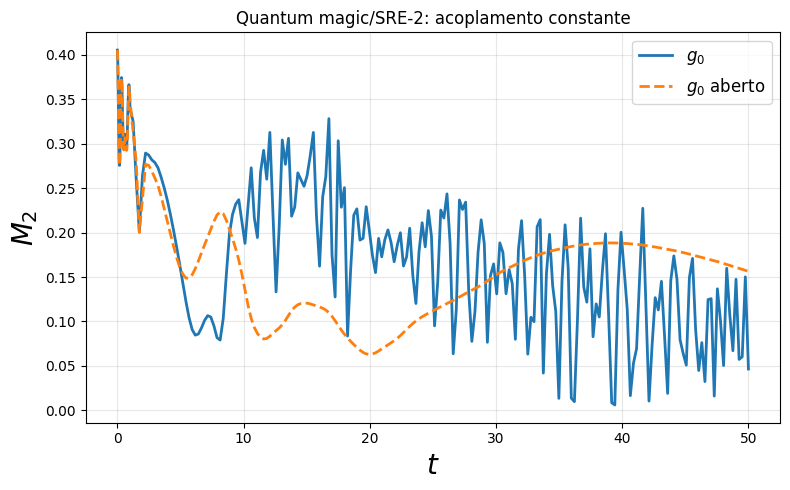

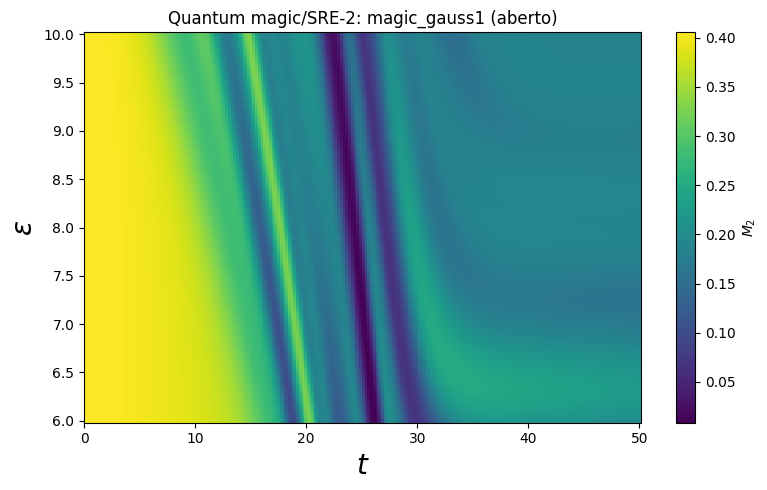

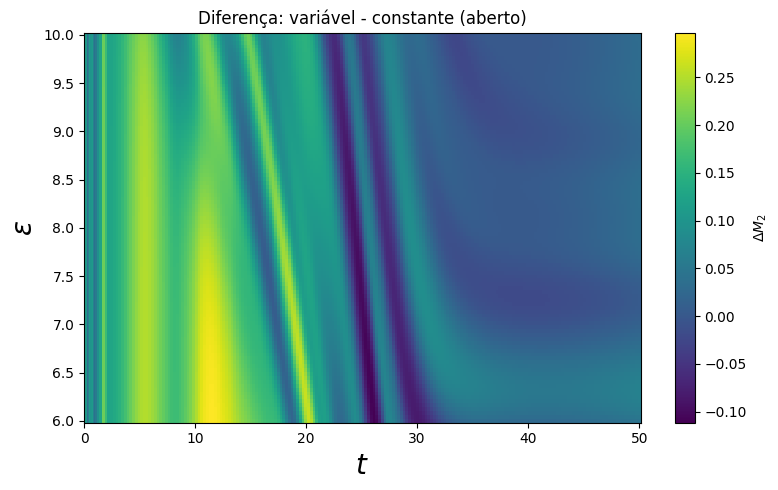

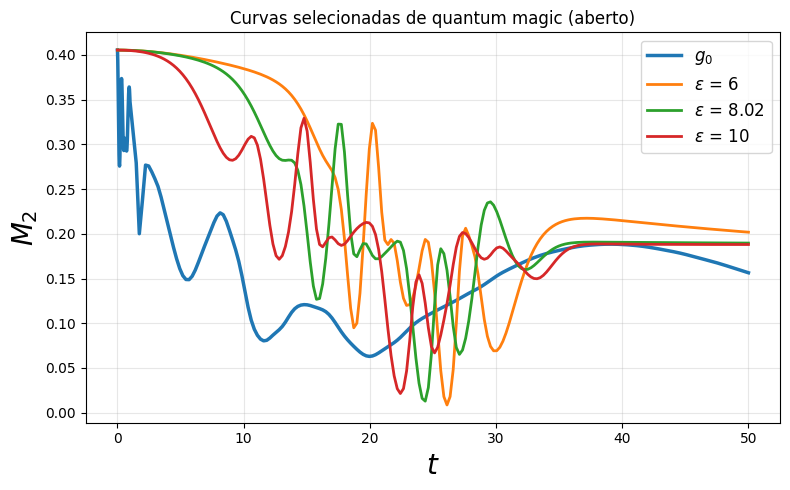

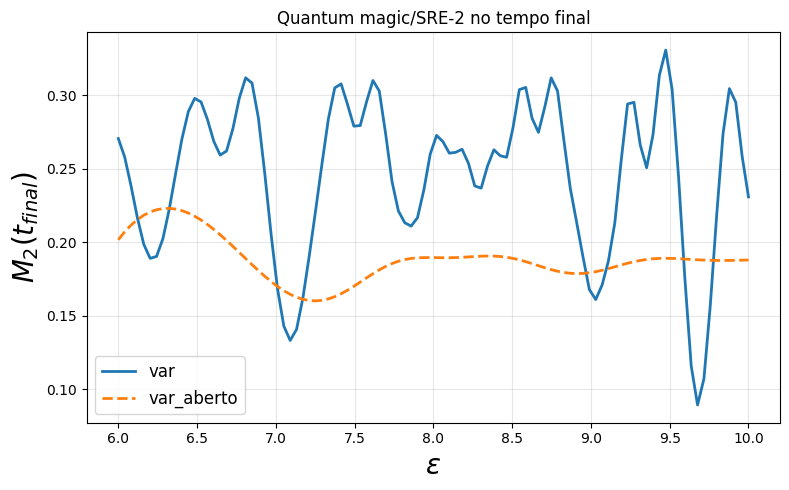

Resumo salvo em: results/magic/magic_gauss1/magic_summary_per_ep.csv


In [16]:
gauss_ep_experiment = latest_magic_experiment("ep")
# Se quiser forçar manualmente, use por exemplo:
# gauss_ep_experiment = "magic_gauss_ep1"

if gauss_ep_experiment is None:
    print("Não encontrei pasta com ep_list.npy/epsilon_list.npy. Rode o caso gauss var ep ou ajuste gauss_ep_experiment manualmente.")
else:
    gauss_ep_results = run_magic_plots(gauss_ep_experiment, indices=None, save=True)


# 4. Gaussiana: variação de $T$

Aqui carregamos a pasta que contém `T_list.npy`, isto é, o caso gaussiano variando a posição do pico temporal:

\begin{equation}
    g(t) = g_0 \exp\left[\sigma\left(\frac{t-T}{\epsilon}\right)^2\right].
\end{equation}


Experimento: magic_gauss2
Pasta: results/magic/magic_gauss2
Parâmetro: T | pontos: 100 | tempos: 300


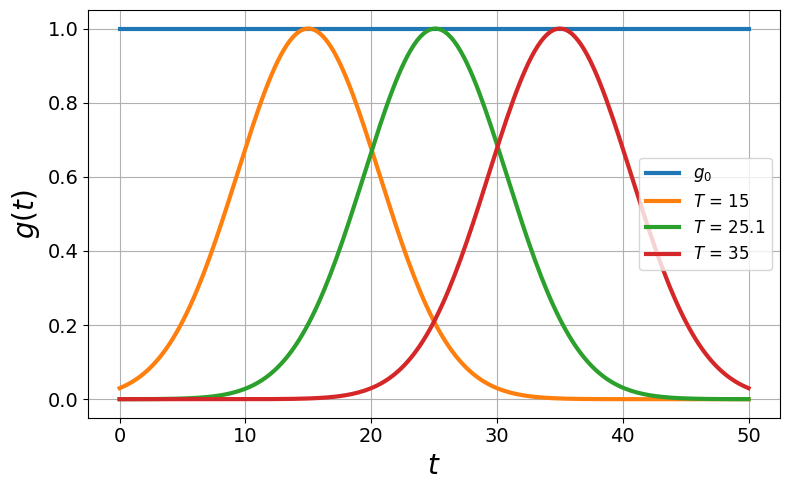

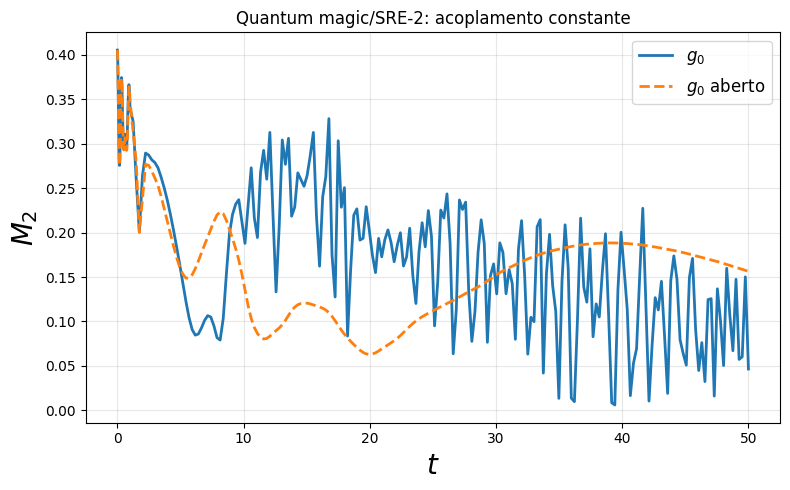

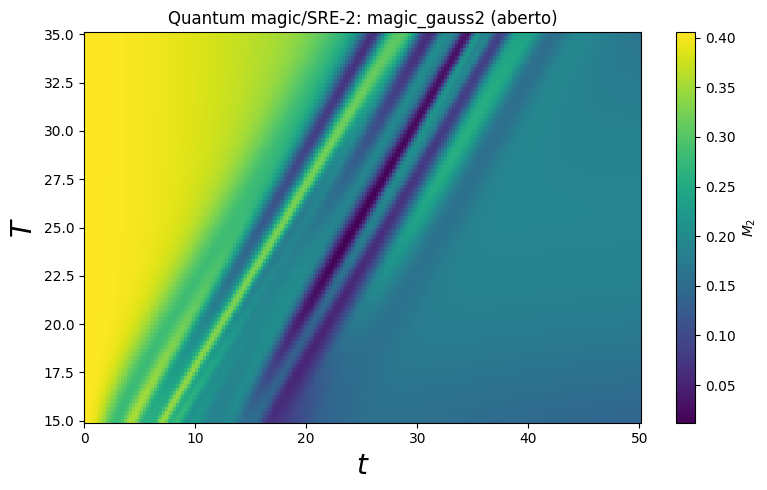

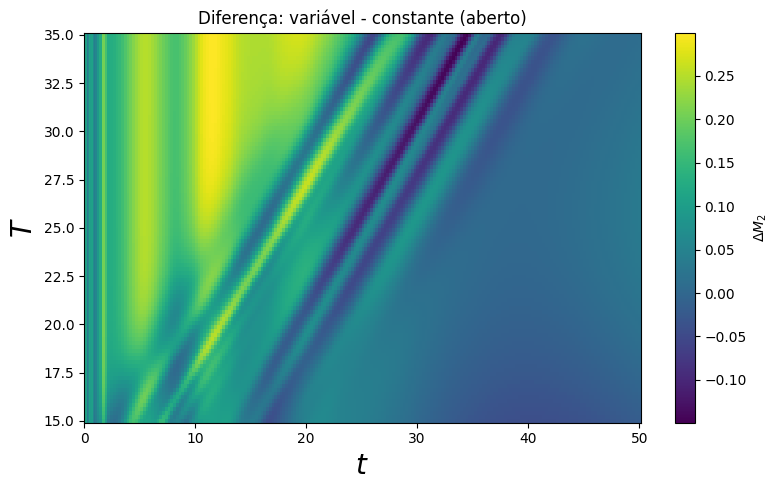

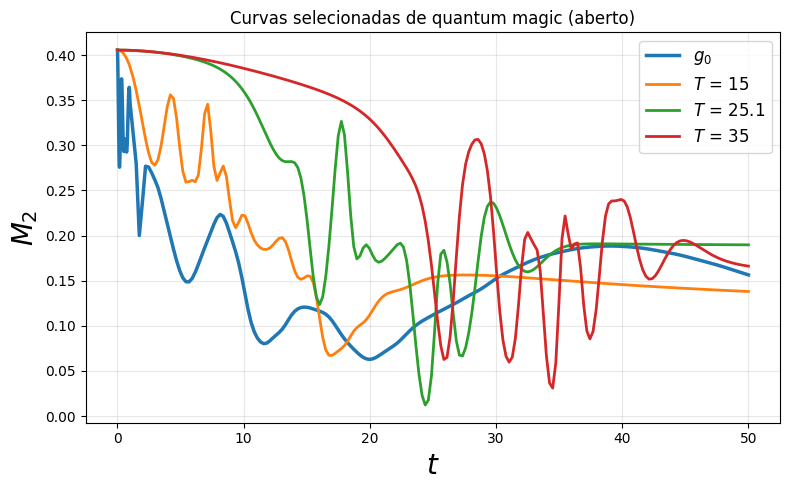

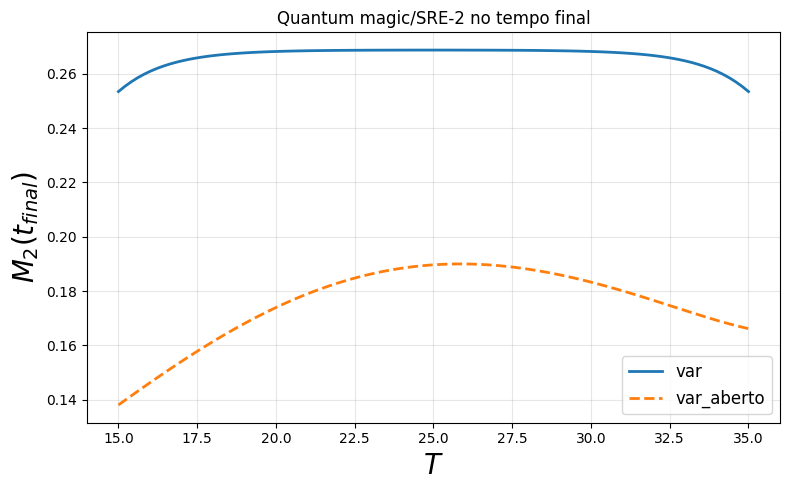

Resumo salvo em: results/magic/magic_gauss2/magic_summary_per_T.csv


In [17]:
gauss_T_experiment = latest_magic_experiment("T")
# Se quiser forçar manualmente, use por exemplo:
# gauss_T_experiment = "magic_gauss1"

if gauss_T_experiment is None:
    print("Não encontrei pasta com T_list.npy. Rode o caso gauss var T ou ajuste gauss_T_experiment manualmente.")
else:
    gauss_T_results = run_magic_plots(gauss_T_experiment, indices=None, save=True)


# 5. Comparação rápida entre experimentos

Esta parte junta as curvas de $M_2(t_{final})$ para os experimentos disponíveis. Como cada varredura tem um parâmetro diferente, os eixos são normalizados para comparação visual.


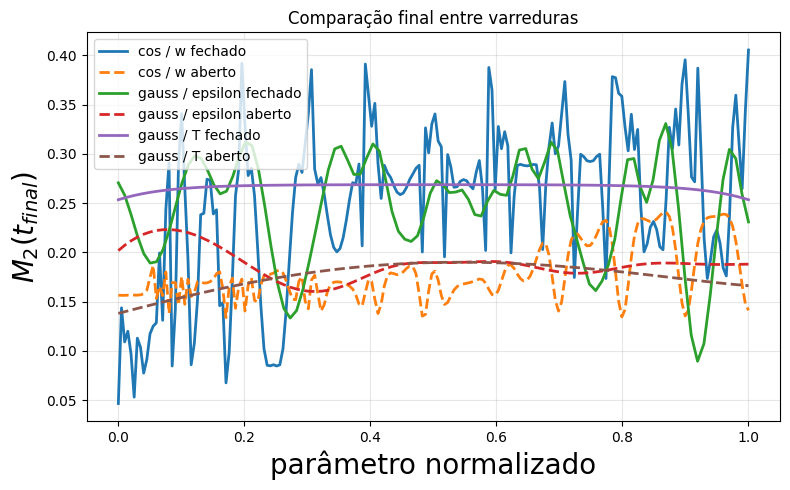

In [18]:
def plot_normalized_final_comparison(experiments, save_path=None):
    plt.figure(figsize=(8, 5))

    for label, experiment in experiments.items():
        if experiment is None:
            continue
        scan, var, D_wt, var_aberto, D_wt_aberto, const, const_aberto, t, info = load_magic(experiment)
        x = (scan - np.min(scan)) / (np.max(scan) - np.min(scan) + 1e-15)
        plt.plot(x, var[:, -1], lw=2.0, label=f"{label} fechado")
        plt.plot(x, var_aberto[:, -1], lw=2.0, linestyle="--", label=f"{label} aberto")

    plt.xlabel("parâmetro normalizado", fontsize=20)
    plt.ylabel(r"$M_2(t_{final})$", fontsize=20)
    plt.title("Comparação final entre varreduras")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=200)
    plt.show()


plot_normalized_final_comparison({
    "cos / w": cos_experiment,
    "gauss / epsilon": gauss_ep_experiment,
    "gauss / T": gauss_T_experiment,
})